#Import Library

In [76]:
# ==========================
# IMPORT LIBRARY
# ==========================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split

from sklearn.preprocessing import LabelEncoder

from sklearn.naive_bayes import GaussianNB
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

from sklearn.metrics import roc_auc_score
from sklearn.model_selection import cross_val_score

import warnings
warnings.filterwarnings("ignore")


#Load Dataset

In [77]:
# ==========================
# LOAD DATASET
# ==========================

df = pd.read_csv("diabetes_prediction_dataset.csv")

df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


#Mengecek Data

In [78]:
# Melihat 5 data pertama
df.head()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
0,Female,80.0,0,1,never,25.19,6.6,140,0
1,Female,54.0,0,0,No Info,27.32,6.6,80,0
2,Male,28.0,0,0,never,27.32,5.7,158,0
3,Female,36.0,0,0,current,23.45,5.0,155,0
4,Male,76.0,1,1,current,20.14,4.8,155,0


In [79]:
# Melihat 5 data terakhir
df.tail()

,gender,age,hypertension,heart_disease,smoking_history,bmi,HbA1c_level,blood_glucose_level,diabetes
99995,Female,80.0,0,0,No Info,27.32,6.2,90,0
99996,Female,2.0,0,0,No Info,17.37,6.5,100,0
99997,Male,66.0,0,0,former,27.83,5.7,155,0
99998,Female,24.0,0,0,never,35.42,4.0,100,0
99999,Female,57.0,0,0,current,22.43,6.6,90,0


In [80]:
# Jumlah baris dan kolom
df.shape

(100000, 9)

In [81]:
# Informasi dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 9 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   gender               100000 non-null  object 
 1   age                  100000 non-null  float64
 2   hypertension         100000 non-null  int64  
 3   heart_disease        100000 non-null  int64  
 4   smoking_history      100000 non-null  object 
 5   bmi                  100000 non-null  float64
 6   HbA1c_level          100000 non-null  float64
 7   blood_glucose_level  100000 non-null  int64  
 8   diabetes             100000 non-null  int64  
dtypes: float64(3), int64(4), object(2)
memory usage: 6.9+ MB


In [82]:
# Statistik data
df.describe()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes
count,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000
mean,41.885856,0.07485,0.039420,27.320767,5.527507,138.058060,0.085000
std,22.516840,0.26315,0.194593,6.636783,1.070672,40.708136,0.278883
min,0.080000,0.00000,0.000000,10.010000,3.500000,80.000000,0.000000
25%,24.000000,0.00000,0.000000,23.630000,4.800000,100.000000,0.000000
50%,43.000000,0.00000,0.000000,27.320000,5.800000,140.000000,0.000000
75%,60.000000,0.00000,0.000000,29.580000,6.200000,159.000000,0.000000
max,80.000000,1.00000,1.000000,95.690000,9.000000,300.000000,1.000000


In [83]:
# Mengecek missing value
df.isnull().sum()

,0
gender,0
age,0
hypertension,0
heart_disease,0
smoking_history,0
bmi,0
HbA1c_level,0
blood_glucose_level,0
diabetes,0


In [84]:
# Mengecek data duplikat
df.duplicated().sum()

np.int64(3854)

In [85]:
df = df.drop_duplicates()

#Melihat Distribusi Target

In [86]:
df["diabetes"].value_counts()

,count
diabetes,
0,87664
1,8482


Visualisasi

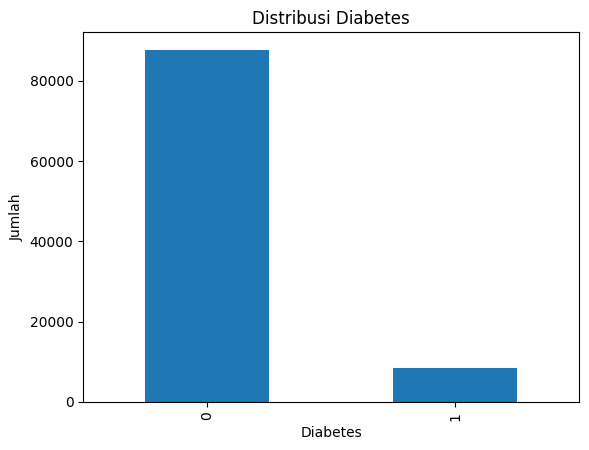

In [87]:
df["diabetes"].value_counts().plot(kind="bar")

plt.title("Distribusi Diabetes")

plt.xlabel("Diabetes")

plt.ylabel("Jumlah")

plt.show()

#Distribusi Usia

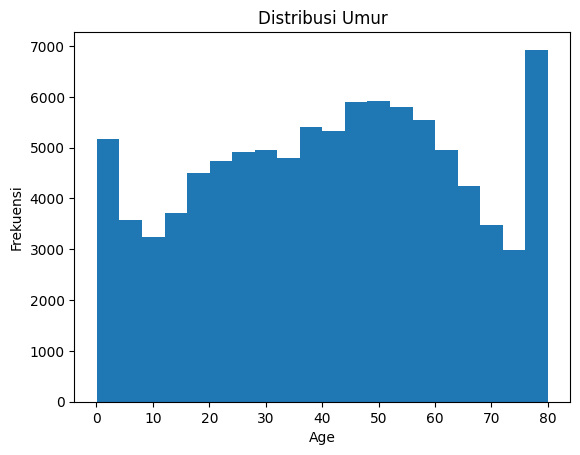

In [88]:
plt.hist(df["age"], bins=20)

plt.title("Distribusi Umur")

plt.xlabel("Age")

plt.ylabel("Frekuensi")

plt.show()

#Distribusi BMI

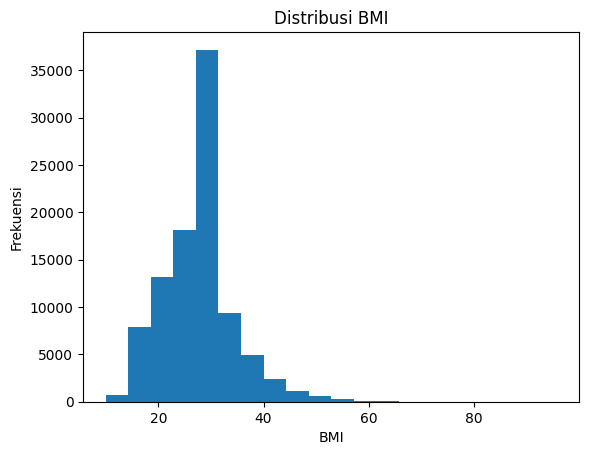

In [89]:
plt.hist(df["bmi"], bins=20)

plt.title("Distribusi BMI")

plt.xlabel("BMI")

plt.ylabel("Frekuensi")

plt.show()

#Distribusi Gula Darah

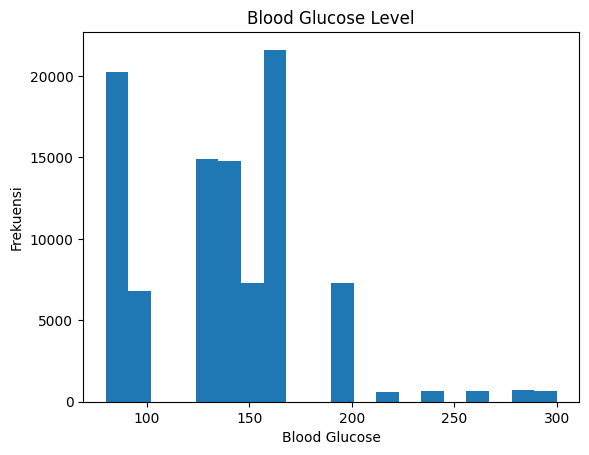

In [90]:
plt.hist(df["blood_glucose_level"], bins=20)

plt.title("Blood Glucose Level")

plt.xlabel("Blood Glucose")

plt.ylabel("Frekuensi")

plt.show()

In [91]:
# One Hot Encoding
df = pd.get_dummies(df,
                    columns=["gender", "smoking_history"],
                    drop_first=True)

df.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,False,False,False,False,False,True,False
1,54.0,0,0,27.32,6.6,80,0,False,False,False,False,False,False,False
2,28.0,0,0,27.32,5.7,158,0,True,False,False,False,False,True,False
3,36.0,0,0,23.45,5.0,155,0,False,False,True,False,False,False,False
4,76.0,1,1,20.14,4.8,155,0,True,False,True,False,False,False,False


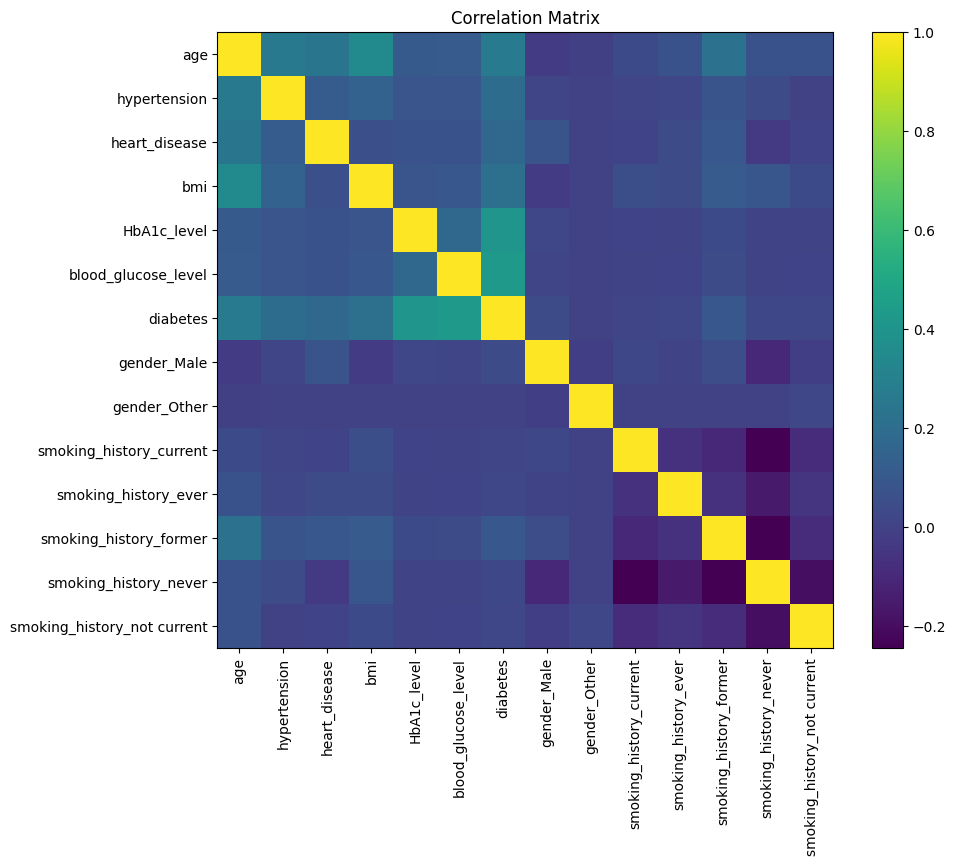

In [93]:
plt.figure(figsize=(10,8))

corr = df.corr()

plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=90)

plt.yticks(range(len(corr.columns)), corr.columns)

plt.title("Correlation Matrix")

plt.show()

#Hasil Encoding

In [92]:
df.head()

,age,hypertension,heart_disease,bmi,HbA1c_level,blood_glucose_level,diabetes,gender_Male,gender_Other,smoking_history_current,smoking_history_ever,smoking_history_former,smoking_history_never,smoking_history_not current
0,80.0,0,1,25.19,6.6,140,0,False,False,False,False,False,True,False
1,54.0,0,0,27.32,6.6,80,0,False,False,False,False,False,False,False
2,28.0,0,0,27.32,5.7,158,0,True,False,False,False,False,True,False
3,36.0,0,0,23.45,5.0,155,0,False,False,True,False,False,False,False
4,76.0,1,1,20.14,4.8,155,0,True,False,True,False,False,False,False


In [94]:
# ==========================
# MEMISAHKAN X DAN Y
# ==========================

X = df.drop("diabetes", axis=1)

y = df["diabetes"]

In [95]:
# ==========================
# SPLIT DATA
# ==========================

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [96]:
print("Training :", X_train.shape)

print("Testing :", X_test.shape)

Training : (76916, 13)
Testing : (19230, 13)


#Naive Bayes

In [97]:
# ==========================
# NAIVE BAYES
# ==========================

nb = GaussianNB()

nb.fit(X_train, y_train)

pred_nb = nb.predict(X_test)

roc_nb = roc_auc_score(y_test, pred_nb)

print("ROC AUC Naive Bayes :", roc_nb)

ROC AUC Naive Bayes : 0.831010441745424


In [98]:
score_nb = cross_val_score(
    GaussianNB(),
    X,
    y,
    cv=5
)

print(score_nb)

print(score_nb.mean())

[0.86921477 0.86660773 0.86504758 0.86405949 0.85449061]
0.8638840374978564


#Hasil Naive Bayes

In [99]:
print("Accuracy Naive Bayes :")

print(accuracy_score(y_test, pred_nb))

Accuracy Naive Bayes :
0.861622464898596


In [100]:
print(confusion_matrix(y_test, pred_nb))

[[15203  2306]
 [  355  1366]]


In [101]:
print(classification_report(y_test, pred_nb))

              precision    recall  f1-score   support

           0       0.98      0.87      0.92     17509
           1       0.37      0.79      0.51      1721

    accuracy                           0.86     19230
   macro avg       0.67      0.83      0.71     19230
weighted avg       0.92      0.86      0.88     19230



#Decision Tree

In [102]:
# ==========================
# DECISION TREE
# ==========================

dt = DecisionTreeClassifier(
    criterion="entropy",
    max_depth=5,
    min_samples_split=10,
    random_state=42
)

dt.fit(X_train, y_train)

pred_dt = dt.predict(X_test)

roc_dt = roc_auc_score(y_test, pred_dt)

print("ROC AUC Decision Tree :", roc_dt)

ROC AUC Decision Tree : 0.8355607205113307


In [103]:
score_dt = cross_val_score(
    DecisionTreeClassifier(
        criterion="entropy",
        max_depth=5,
        random_state=42
    ),
    X,
    y,
    cv=5
)

print(score_dt)

print(score_dt.mean())

[0.97108684 0.97150138 0.9684851  0.97191742 0.97082532]
0.9707632109122317


#Hasil Decision Tree

In [104]:
print("Accuracy Decision Tree :")

print(accuracy_score(y_test, pred_dt))

Accuracy Decision Tree :
0.970566822672907


In [105]:
print(confusion_matrix(y_test, pred_dt))

[[17509     0]
 [  566  1155]]


In [106]:
print(classification_report(y_test, pred_dt))

              precision    recall  f1-score   support

           0       0.97      1.00      0.98     17509
           1       1.00      0.67      0.80      1721

    accuracy                           0.97     19230
   macro avg       0.98      0.84      0.89     19230
weighted avg       0.97      0.97      0.97     19230



#Perbandingan Akurasi

In [107]:
hasil = pd.DataFrame({
    "Model": ["Naive Bayes","Decision Tree"],
    "Accuracy": [
        accuracy_score(y_test,pred_nb),
        accuracy_score(y_test,pred_dt)
    ]
})

hasil

,Model,Accuracy
0,Naive Bayes,0.861622
1,Decision Tree,0.970567


#Grafik Perbandingan

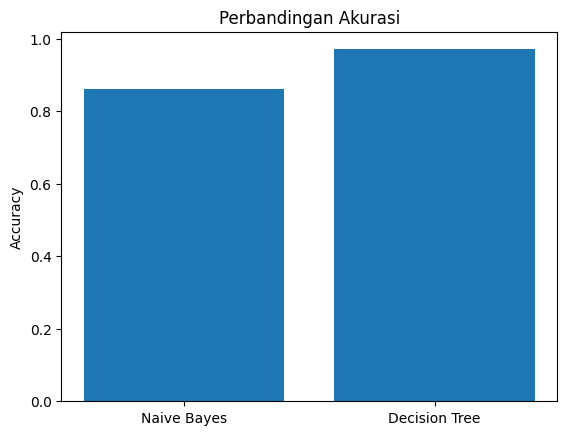

In [108]:
plt.bar(hasil["Model"], hasil["Accuracy"])

plt.title("Perbandingan Akurasi")

plt.ylabel("Accuracy")

plt.show()

#Feature Importance

In [109]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":dt.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

print(importance)

                        Feature  Importance
4                   HbA1c_level    0.605312
5           blood_glucose_level    0.341427
0                           age    0.053261
2                 heart_disease    0.000000
1                  hypertension    0.000000
3                           bmi    0.000000
6                   gender_Male    0.000000
7                  gender_Other    0.000000
8       smoking_history_current    0.000000
9          smoking_history_ever    0.000000
10       smoking_history_former    0.000000
11        smoking_history_never    0.000000
12  smoking_history_not current    0.000000


#Visualisasi Feature Importance

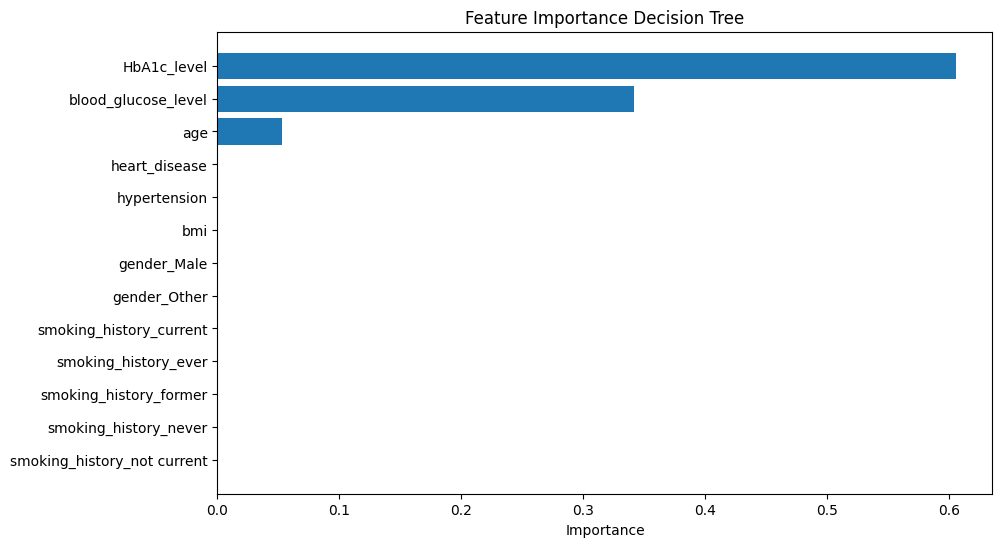

In [110]:
plt.figure(figsize=(10,6))

plt.barh(
    importance["Feature"],
    importance["Importance"]
)

plt.xlabel("Importance")

plt.title("Feature Importance Decision Tree")

plt.gca().invert_yaxis()

plt.show()